# Superstore Data Analysis (Python - Pandas, Matplotlib & Seaborn)

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
# Load dataset
df = pd.read_csv('SampleSuperstore.csv')

# Data cleaning
df.dropna(inplace=True)

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## KPI Analysis

## 1. Total Sales

In [ ]:
print("Total Sales:", df['Sales'].sum())

Total Sales: 2297200.8603000003


## 2. Total Profit


In [ ]:
print("Total Profit:", df['Profit'].sum())

Total Profit: 286397.0217


## 3. Total Orders

In [ ]:
print("Total Orders:", df.shape[0])

Total Orders: 9994


## 4. Average Profit

In [ ]:
print("Average Profit:", df['Profit'].mean())

Average Profit: 28.65689630778467


## 5. Total Quantity

In [ ]:
print("Total Quantity:", df['Quantity'].sum())

Total Quantity: 37873


## Analysis & Visualization

## 6. Top Selling Sub-Categories

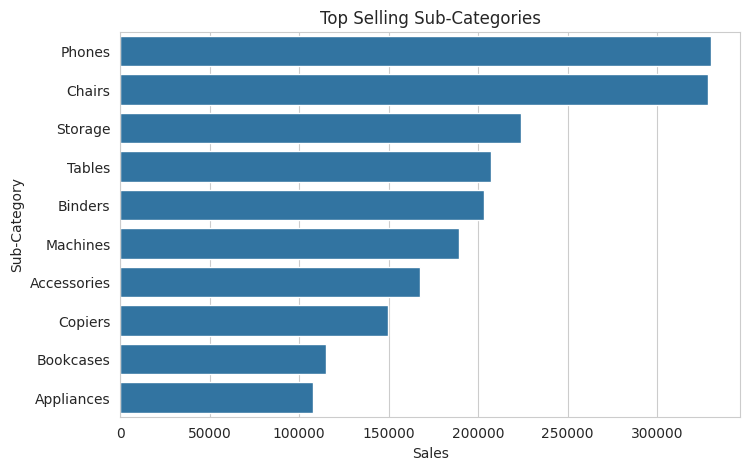

In [ ]:
top_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_sales.values, y=top_sales.index)
plt.title("Top Selling Sub-Categories")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.show()

## 7. Most Profitable Sub-Categories

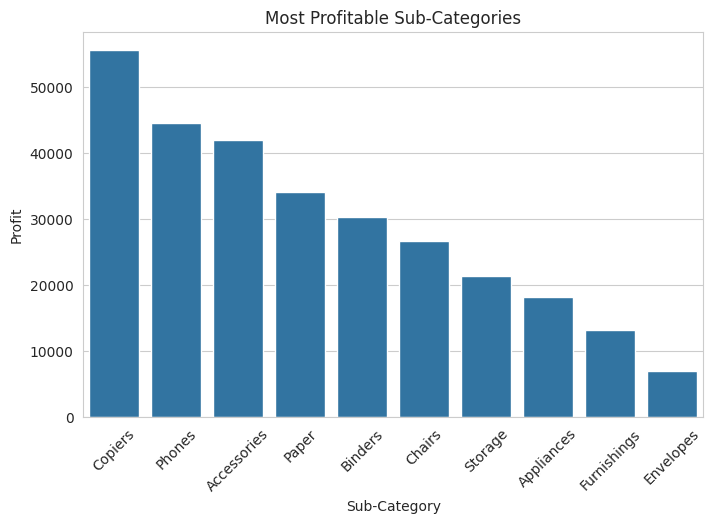

In [ ]:
top_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_profit.index, y=top_profit.values)
plt.title("Most Profitable Sub-Categories")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

## 8. Loss-Making Sub-Categories (Pie Chart)

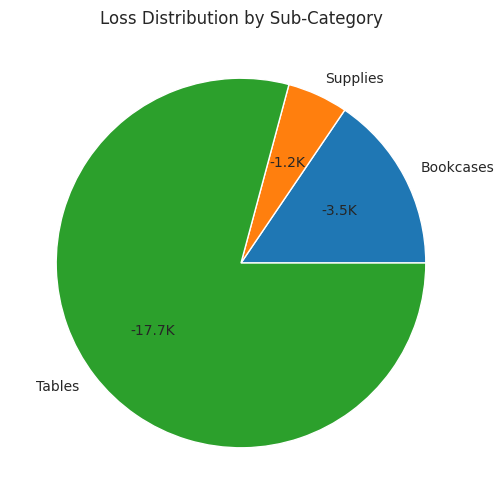

In [ ]:
loss = df.groupby('Sub-Category')['Profit'].sum()
loss = loss[loss < 0]
loss_abs = loss.abs()
plt.figure(figsize=(6,6))
loss_abs.plot(kind='pie', autopct=show_negative)
plt.title("Loss Distribution by Sub-Category")
plt.ylabel("")
plt.show()

## 9. Sales by Category (show values instead of percentage)

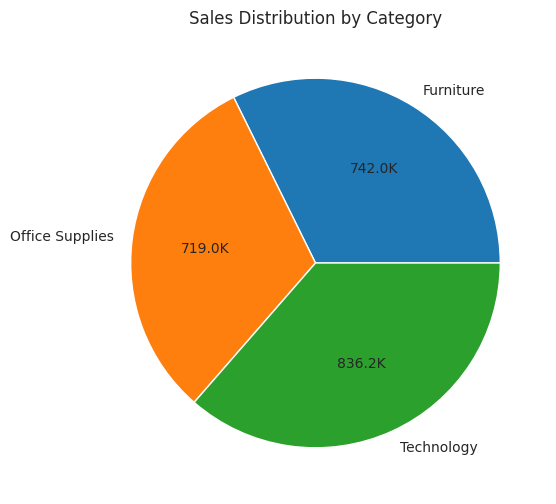

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(6,6))
category_sales.plot(kind='pie', autopct=show_value)

plt.title("Sales Distribution by Category")
plt.ylabel("")
plt.show()

## 10. Sales vs Profit by Region


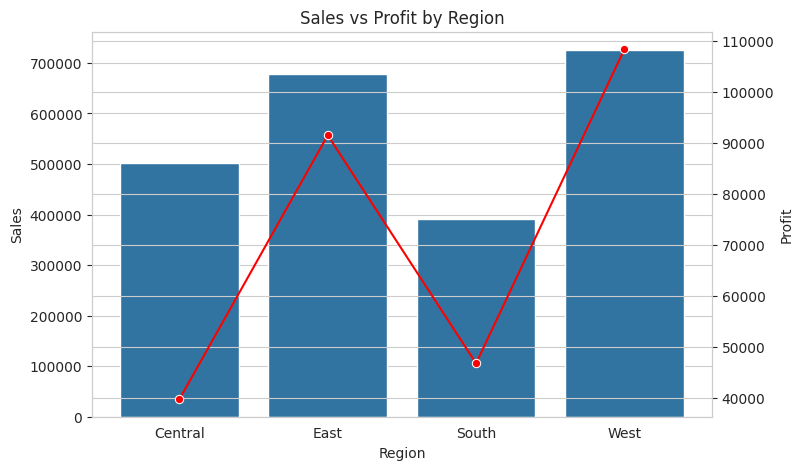

In [ ]:
region_data = df.groupby('Region').agg({'Sales':'sum','Profit':'sum'})
fig, ax1 = plt.subplots(figsize=(8,5))
sns.barplot(x=region_data.index, y=region_data['Sales'], ax=ax1)
ax2 = ax1.twinx()
sns.lineplot(x=region_data.index, y=region_data['Profit'], ax=ax2, marker='o', color='red')
plt.title("Sales vs Profit by Region")
plt.show()